In [1]:
import numpy as np
from scipy.linalg import inv, eig
import cvxpy as cp
import matplotlib.pyplot as plt
import matplotlib as mpl

import time
import tracemalloc



from src.data_driven import Plant, Cloud

from src.constants import (As, Bs) # system model
from src.constants import (T, KEY_RANGE, 
                       GAMMA_RANGE, INPUT_RANGE,
                         INITIAL_STATE_RANGE,
                           MAX_DISTURBANCE, SIM_INIT_STATE_RANGE) 

In [2]:

def print_experiment_parameters():
    """
    Prints the system and experiment parameters.
    """
    print(f"Trajectory length for generating data: {T}")
    print(f"Input range for the system: {INPUT_RANGE}")
    print(f"Initial state range for the system: {INITIAL_STATE_RANGE}")
    print(f"Key range for random matrices F1 and G1: {KEY_RANGE}")
    print(f"Maximum for disturbance: {MAX_DISTURBANCE}")




# System and experiment parameters
print_experiment_parameters()

Trajectory length for generating data: 20
Input range for the system: 5
Initial state range for the system: 2.5
Key range for random matrices F1 and G1: 1
Maximum for disturbance: 0


In [3]:
# initializing plant and cloud 
plant = Plant(As, Bs)
cloud = Cloud()


In [4]:

n = plant.num_states # number of states
m = plant.num_inputs # number of inputs

x0 = plant.random_matrix(n, 1, 1) # random initial state

# Define the range of max disturbance
max_disturbance_values = np.arange(0, 0.21, 0.01)
eigenvalue_results = []
controller_results = []
kbar_results = []

gamma_max_values = []
state_energy_disturbance = {}

time_key_gen = []
ram_key_gen = []
time_controller = []
ram_controller = []

time_k_calc = []
ram_k_calc = []

for MAX_DISTURBANCE in max_disturbance_values:
    X1, X0, U0, D0 = plant.collecting_trajectories(T, INPUT_RANGE, INITIAL_STATE_RANGE, MAX_DISTURBANCE)

    tracemalloc.start()
    t_start = time.time()

    F1, G1 = plant.key_generation(n, m, KEY_RANGE)
    X1_tilde, X0_tilde, V0 = plant.transforming_data(X1, X0, U0, F1, G1)

    time_key_gen.append(time.time() - t_start)
    ram_key_gen.append(tracemalloc.get_traced_memory()[1])
    tracemalloc.stop()


    tracemalloc.start()
    t_start = time.time()

    bA, bB, bC, bQ = cloud.ellipsoid_parameters(X1_tilde, X0_tilde, V0, MAX_DISTURBANCE)
    gamma_results = np.zeros((len(GAMMA_RANGE), 1))
    Kbar = np.zeros((m, n))    
    for gam, gamma in enumerate(GAMMA_RANGE):
        try:
            prob, P, Y = cloud.get_controller_cvxpy(bA, bB, bC, gamma)
            if prob.status == "infeasible":
                gamma_results[gam, 0] = -1
            else:
                gamma_results[gam, 0] = gamma
                Kbar = Y @ np.linalg.inv(P)
        except:
            gamma_results[gam, 0] = -1
    
    gamma_bar = np.max(gamma_results)
    gamma_max_values.append(gamma_bar)
  
    time_controller.append(time.time() - t_start)
    ram_controller.append(tracemalloc.get_traced_memory()[1])
    tracemalloc.stop()




    tracemalloc.start()
    t_start = time.time() 
    # for whatever reason we did not get results then we report instability  
    if gamma_bar == -1.0:
        K = Kbar
    else:
        K = F1 + (np.eye(m) + G1) @ Kbar

    time_k_calc.append(time.time() - t_start)
    ram_k_calc.append(tracemalloc.get_traced_memory()[1])
    tracemalloc.stop()    

    

    eig_closed_loop = np.abs(np.linalg.eigvals(As + Bs @ K))
    
    max_eigenvalue = np.max(eig_closed_loop)
    eigenvalue_results.append(max_eigenvalue)
    controller_results.append(K)
    kbar_results.append(Kbar)
    
    print(f"MAX_DISTURBANCE: {MAX_DISTURBANCE}, Max Eigenvalue: {max_eigenvalue}, Gamma Bar: {gamma_bar}")


    X = np.zeros((n, T + 1))
    X[:, [0]] = x0

    for i in range(T):
        u = K @ X[:,[i]]
        d = (np.random.rand(n, 1) * (2 * MAX_DISTURBANCE)) - MAX_DISTURBANCE
        X[:,[i+1]] = As @ X[:,[i]] + Bs @ (u) + d
        state_energy_disturbance[f"max_dis_{MAX_DISTURBANCE}"] = np.sqrt(sum(X**2)).reshape(-1, 1) 

MAX_DISTURBANCE: 0.0, Max Eigenvalue: 0.43505997551864595, Gamma Bar: 0.026000000000000002
MAX_DISTURBANCE: 0.01, Max Eigenvalue: 0.5082695900659112, Gamma Bar: 0.044
MAX_DISTURBANCE: 0.02, Max Eigenvalue: 0.5550111267446777, Gamma Bar: 0.003
MAX_DISTURBANCE: 0.03, Max Eigenvalue: 0.4629455825278336, Gamma Bar: 0.008
MAX_DISTURBANCE: 0.04, Max Eigenvalue: 0.4624887948987612, Gamma Bar: 0.008
MAX_DISTURBANCE: 0.05, Max Eigenvalue: 0.5380480656084621, Gamma Bar: 0.009000000000000001
MAX_DISTURBANCE: 0.06, Max Eigenvalue: 0.4721009397391232, Gamma Bar: 0.008
MAX_DISTURBANCE: 0.07, Max Eigenvalue: 0.40460966852429553, Gamma Bar: 0.007
MAX_DISTURBANCE: 0.08, Max Eigenvalue: 0.5968073921815655, Gamma Bar: 0.0
MAX_DISTURBANCE: 0.09, Max Eigenvalue: 0.45626488826421047, Gamma Bar: 0.015
MAX_DISTURBANCE: 0.1, Max Eigenvalue: 0.4675642679921691, Gamma Bar: 0.001
MAX_DISTURBANCE: 0.11, Max Eigenvalue: 0.4894745304315132, Gamma Bar: 0.001
MAX_DISTURBANCE: 0.12, Max Eigenvalue: 0.4107980726510455, 

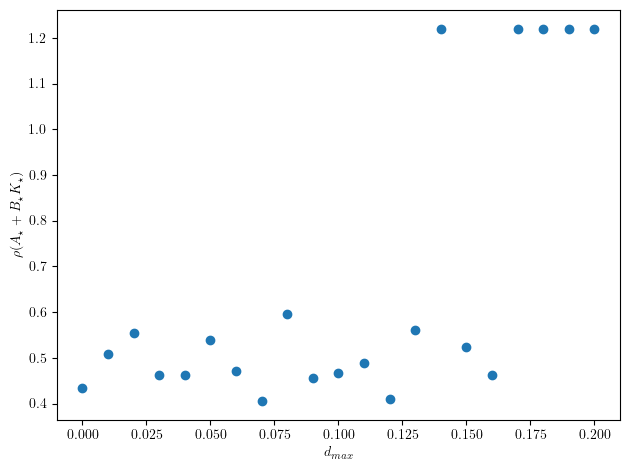

In [5]:

# Set the font settings
mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['ps.fonttype'] = 42
mpl.rc('text', usetex=True)
mpl.rc('font', family='serif')

fig = plt.figure()
ax = fig.subplots(1,1)

# Plot max eigenvalue as a function of max disturbance
# plt.figure(figsize=(10, 5))
ax.plot(max_disturbance_values, eigenvalue_results, marker='o', linestyle='')

ax.set(xlabel=r"$d_{max}$", ylabel=r"$\rho(A_\star+B_\star K_\star)$")
plt.tight_layout()

fig.savefig("disturbance_max_eigen_value.pdf", transparent=True)
plt.show()




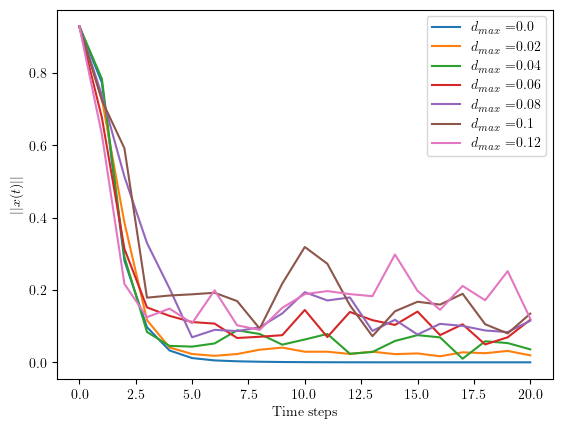

In [6]:
# Plot state energy for the first 10 disturbances
fig = plt.figure()
ax = fig.subplots(1,1)
for key, energy in list(state_energy_disturbance.items())[0:14:2]:
    dmax_value = key.split('_')[-1]
    label = f"dmax = {dmax_value}"
    label = key.replace('max_dis_', r"$d_{max} = $")
    ax.plot(energy, label=label)
ax.set_ylabel(r"$||x(t)||$")
ax.set_xlabel("Time steps")
plt.legend()

fig.savefig("state_energy_max_disturbance.pdf", transparent=True)
plt.show()

In [7]:
# Compute and print average time and memory usage
def convert_to_kb(memory_list):
    return [mem / 1024 for mem in memory_list]

avg_time_key_gen = np.mean(time_key_gen)
avg_ram_key_gen = np.mean(convert_to_kb(ram_key_gen))
avg_time_controller = np.mean(time_controller)
avg_ram_controller = np.mean(convert_to_kb(ram_controller))
avg_time_k_calc = np.mean(time_k_calc)
avg_ram_k_calc = np.mean(convert_to_kb(ram_k_calc))

print(f"Average Time for Key Generation: {avg_time_key_gen:.6f} s, Memory: {avg_ram_key_gen:.2f} KB")
print(f"Average Time for Controller Computation: {avg_time_controller:.6f} s, Memory: {avg_ram_controller:.2f} KB")
print(f"Average Time for K Calculation: {avg_time_k_calc:.6f} s, Memory: {avg_ram_k_calc:.2f} KB")

Average Time for Key Generation: 0.000394 s, Memory: 5.84 KB
Average Time for Controller Computation: 5.589960 s, Memory: 378.14 KB
Average Time for K Calculation: 0.000102 s, Memory: 4.16 KB
